# Robust likelihoods: Student-t vs the multivariate normal

The multivariate-normal likelihood penalizes a residual quadratically, so a few
outliers — mislabeled points, an unreported background, a transcription error —
leave it **confidently wrong**: the posterior stays narrow around a biased value.
The **Student-t** likelihood keeps the same covariance $\Sigma$ but replaces the
Gaussian functional with a heavy-tailed one carrying a degrees-of-freedom
parameter $\nu$: small $\nu$ means heavy tails, $\nu \to \infty$ recovers the
Gaussian.  Sampling $\nu$ lets the *data* decide how heavy the tails need to be
— and, as we will see, the multivariate-t's honesty shows up as **wider,
truth-covering uncertainty**, not as outlier rejection.


In [1]:
import corner
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats

import rxmc

rng = np.random.default_rng(21)

Using database version X4-2024-12-31 located in: /home/kyle/db/exfor/unpack_exfor-2024/X4-2024-12-31


## A clean linear signal with a few gross outliers

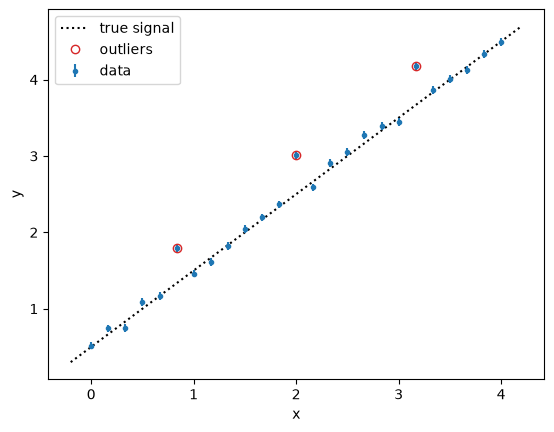

In [2]:
class LinearModel(rxmc.physical_model.PhysicalModel):
    def __init__(self):
        super().__init__(
            [rxmc.params.Parameter("m", float), rxmc.params.Parameter("b", float)]
        )

    def evaluate(self, observation, m, b):
        return self.y(observation.x, m, b)

    def y(self, x, m, b):
        return m * x + b


model = LinearModel()
m_true, b_true = 1.0, 0.5
noise = 0.05

x = np.linspace(0.0, 4.0, 25)
y = model.y(x, m_true, b_true) + rng.normal(0.0, noise, x.size)

outliers = np.array([5, 12, 19])
y[outliers] += np.array([10.0, 12.0, 9.0]) * noise  # one-sided: a fake background

obs = rxmc.observation.Observation(x=x, y=y, y_stat_err=noise * np.ones_like(y))

xg = np.linspace(-0.2, 4.2, 100)
plt.plot(xg, model.y(xg, m_true, b_true), "k:", label="true signal")
plt.errorbar(x, y, noise, ls="none", marker=".", label="data")
plt.plot(x[outliers], y[outliers], "o", mfc="none", color="tab:red", label="outliers")
plt.xlabel("x")
plt.ylabel("y")
plt.legend();

## The same constraint, two likelihood functionals

The likelihood functional is orthogonal to the covariance: both constraints below
share the identical statistical $\Sigma$; only the function of
$(d^2, \log\det\Sigma, n)$ differs.  The Student-t brings one likelihood-side
parameter, and the **full-tuple convention** applies everywhere: every
`Constraint` method takes covariance parameters followed by likelihood
parameters, in `constraint.params` order — including `chi2`, even though the
chi-squared statistic ignores $\nu$.


In [3]:
nu_param = rxmc.params.Parameter(
    "degrees_of_freedom", float, latex_name=r"\nu", bounds=(1.0, 100.0)
)

c_gauss = rxmc.constraint.Constraint([obs], model)
c_t = rxmc.constraint.Constraint(
    [obs], model, likelihood=rxmc.likelihood_model.StudentT(nu_parameter=nu_param)
)

print("Gaussian constraint params:", [p.name for p in c_gauss.params])
print("Student-t constraint params:", [p.name for p in c_t.params])

Gaussian constraint params: []
Student-t constraint params: ['degrees_of_freedom']


## Sampling $\nu$ alongside the model

$\nu$ is a likelihood parameter, so it goes to a `likelihood_samplers` entry in
the `Walker` — the Gibbs framework alternates between the physics block and the
nuisance block.


In [4]:
model_prior = stats.multivariate_normal(mean=[1.0, 0.5], cov=np.diag([0.3, 0.3]) ** 2)


def make_model_sampler():
    return rxmc.param_sampling.BatchedAdaptiveMetropolisSampler(
        params=model.params,
        starting_location=model_prior.mean,
        prior=model_prior,
        initial_proposal_cov=model_prior.cov / 100,
    )


nu_prior = stats.multivariate_normal(mean=[10.0], cov=[[49.0]])
nu_sampler = rxmc.param_sampling.BatchedAdaptiveMetropolisSampler(
    params=list(c_t.params),
    starting_location=np.array([10.0]),
    prior=nu_prior,
    initial_proposal_cov=np.array([[4.0]]),
)

walker_gauss = rxmc.walker.Walker(
    make_model_sampler(),
    rxmc.evidence.Evidence([c_gauss]),
    rng=np.random.default_rng(1),
)
walker_t = rxmc.walker.Walker(
    make_model_sampler(),
    rxmc.evidence.Evidence([c_t]),
    likelihood_samplers=[nu_sampler],
    rng=np.random.default_rng(2),
)

for walker in (walker_gauss, walker_t):
    walker.walk(n_steps=6000, burnin=2000, batch_size=1000, verbose=False)

chain_gauss = walker_gauss.model_sampler.chain
chain_t = walker_t.model_sampler.chain
nu_chain = walker_t.likelihood_samplers[0].chain

for name, ch in [("Gaussian", chain_gauss), ("Student-t", chain_t)]:
    z = abs(ch[:, 1].mean() - b_true) / ch[:, 1].std()
    print(
        f"{name:10s}  m = {ch[:, 0].mean():.3f} ± {ch[:, 0].std():.3f}   "
        f"b = {ch[:, 1].mean():.3f} ± {ch[:, 1].std():.3f}   "
        f"(truth b = {b_true} is {z:.1f} sigma away)"
    )

Gaussian    m = 1.002 ± 0.008   b = 0.566 ± 0.019   (truth b = 0.5 is 3.4 sigma away)
Student-t   m = 1.002 ± 0.028   b = 0.562 ± 0.067   (truth b = 0.5 is 0.9 sigma away)


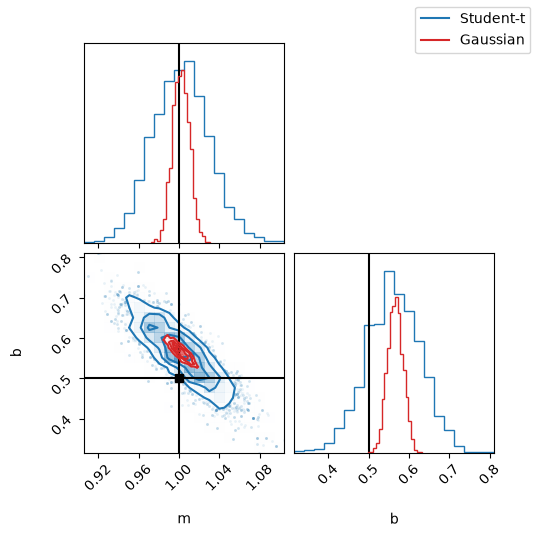

In [5]:
fig = corner.corner(
    chain_t,
    labels=["m", "b"],
    truths=[m_true, b_true],
    truth_color="k",
    color="tab:blue",
)
corner.corner(chain_gauss, fig=fig, color="tab:red")
plt.plot([], [], color="tab:blue", label="Student-t")
plt.plot([], [], color="tab:red", label="Gaussian")
fig.legend(loc="upper right");

Both posteriors are shifted by the one-sided outliers — but the Gaussian is
**confidently wrong** (truth excluded at $\sim 3.5\sigma$) while the Student-t
inflates its uncertainty until the truth is covered ($\lesssim 1\sigma$).

This is the multivariate-t's character: it carries **one** radial tail factor
for the whole stacked residual, so it cannot single out and reject individual
points — it broadens the posterior instead of relocating it.  Per-point outlier
rejection would need per-point machinery (e.g. a free noise nuisance via
`noise_term`, or explicitly masking suspect points).


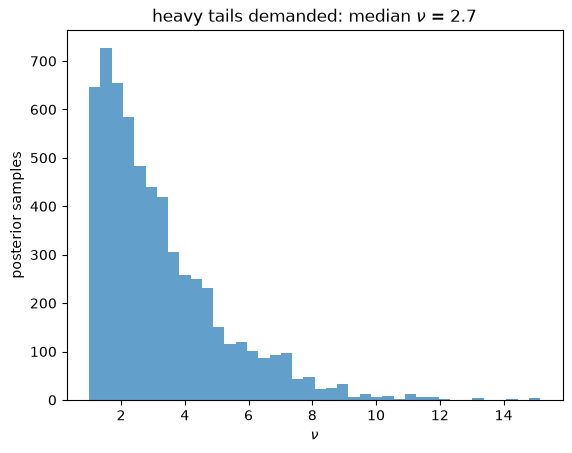

In [6]:
plt.hist(nu_chain[:, 0], bins=40, color="tab:blue", alpha=0.7)
plt.xlabel(r"$\nu$")
plt.ylabel("posterior samples")
plt.title(f"heavy tails demanded: median $\\nu$ = {np.median(nu_chain):.1f}");

## `chi2`: the fit statistic without the normalization

`Constraint.chi2` returns the generalized chi-squared (the squared Mahalanobis
distance) under the same $\Sigma$.  Note the full-tuple convention: the
Student-t constraint requires $\nu$ in the tuple even though the statistic
ignores it.


In [7]:
map_gauss = chain_gauss[np.argmax(walker_gauss.model_sampler.logp_chain)]
map_t = chain_t[np.argmax(walker_t.model_sampler.logp_chain)]
nu_map = float(np.median(nu_chain))

chi2_gauss = c_gauss.chi2(tuple(map_gauss))
chi2_t = c_t.chi2(tuple(map_t), (nu_map,))
print(f"Gaussian  chi2/n = {chi2_gauss / obs.n_data_pts:.2f}")
print(f"Student-t chi2/n = {chi2_t / obs.n_data_pts:.2f}")

Gaussian  chi2/n = 10.98
Student-t chi2/n = 10.98


## Predictive comparison

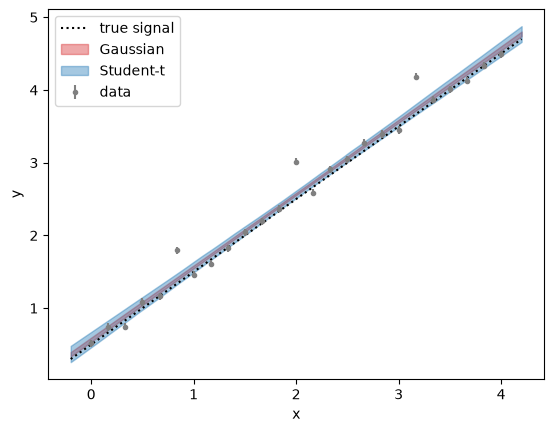

In [8]:
def band(chain, levels=(5, 95)):
    draws = chain[:: max(1, len(chain) // 300)]
    ys = np.array([model.y(xg, *p) for p in draws])
    return np.percentile(ys, levels, axis=0)


lo_g, hi_g = band(chain_gauss)
lo_t, hi_t = band(chain_t)

plt.plot(xg, model.y(xg, m_true, b_true), "k:", label="true signal")
plt.errorbar(x, y, noise, ls="none", marker=".", color="gray", label="data")
plt.fill_between(xg, lo_g, hi_g, alpha=0.4, color="tab:red", label="Gaussian")
plt.fill_between(xg, lo_t, hi_t, alpha=0.4, color="tab:blue", label="Student-t")
plt.xlabel("x")
plt.ylabel("y")
plt.legend();

## Takeaways

- **The likelihood functional is a drop-in choice**: `Constraint(...,
  likelihood=StudentT())` keeps the covariance model identical and changes only
  the function of $(d^2, \log\det\Sigma, n)$.
- **$\nu$ is an ordinary nuisance parameter** — give it bounds on its
  `Parameter`, a prior, and a `likelihood_samplers` entry, and the data choose
  the tail weight.
- **The multivariate-t buys honesty, not outlier rejection**: one shared tail
  factor widens the posterior to cover the truth where the Gaussian is
  confidently biased; rejecting individual points needs per-point terms.
- **The full-tuple convention is uniform**: every method — `log_likelihood`,
  `chi2`, `covariance_matrix` — takes covariance parameters then likelihood
  parameters in `constraint.params` order, and raises on a wrong count instead
  of guessing.
